In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
import warnings

import json

warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ All imports successful!")
print("✅ Ready to start classification task!")

✅ All imports successful!
✅ Ready to start classification task!


In [5]:
print("\n" + "=" * 80)
print("CELL 2: DATASET LOADING & AUDIT (A1)")
print("=" * 80)

# Load the dataset
df = pd.read_csv('../../data/raw/gym_members_exercise_tracking.csv')

print(f"\n📊 SHAPE: {df.shape[0]} rows × {df.shape[1]} columns")

# Column names and data types
print("\n📋 COLUMNS & DATA TYPES:")
print(df.dtypes)

# First 5 rows
print("\n📄 FIRST 5 ROWS:")
print(df.head())

# Data Info
print("\n🔍 DETAILED INFO:")
print(df.info())

# Missing values
print("\n❌ MISSING VALUES:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   ✅ No missing values! Dataset is clean.")
else:
    print(missing[missing > 0])

# Target variable - Workout_Type distribution
print("\n🎯 TARGET VARIABLE: Workout_Type")
print("\nClass Distribution (Counts):")
print(df['Workout_Type'].value_counts())
print("\nClass Distribution (Percentage):")
print((df['Workout_Type'].value_counts(normalize=True) * 100).round(2))

# Duplicate check
print(f"\n🔄 DUPLICATES: {df.duplicated().sum()} duplicate rows")

# Basic statistics
print("\n📈 BASIC STATISTICS:")
print(df.describe())

print("\n" + "=" * 80)
print("✅ AUDIT COMPLETE - Dataset is ready for EDA")
print("=" * 80)


CELL 2: DATASET LOADING & AUDIT (A1)

📊 SHAPE: 973 rows × 15 columns

📋 COLUMNS & DATA TYPES:
Age                                int64
Gender                               str
Weight (kg)                      float64
Height (m)                       float64
Max_BPM                            int64
Avg_BPM                            int64
Resting_BPM                        int64
Session_Duration (hours)         float64
Calories_Burned                  float64
Workout_Type                         str
Fat_Percentage                   float64
Water_Intake (liters)            float64
Workout_Frequency (days/week)      int64
Experience_Level                   int64
BMI                              float64
dtype: object

📄 FIRST 5 ROWS:
   Age  Gender  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  \
0   56    Male         88.3        1.71      180      157           60   
1   46  Female         74.9        1.53      179      151           66   
2   32  Female         68.1        1.


CELL 3: EDA - DISTRIBUTIONS & CORRELATIONS (A2 - Part 1)

1️⃣ Creating distribution plots for all numerical features...


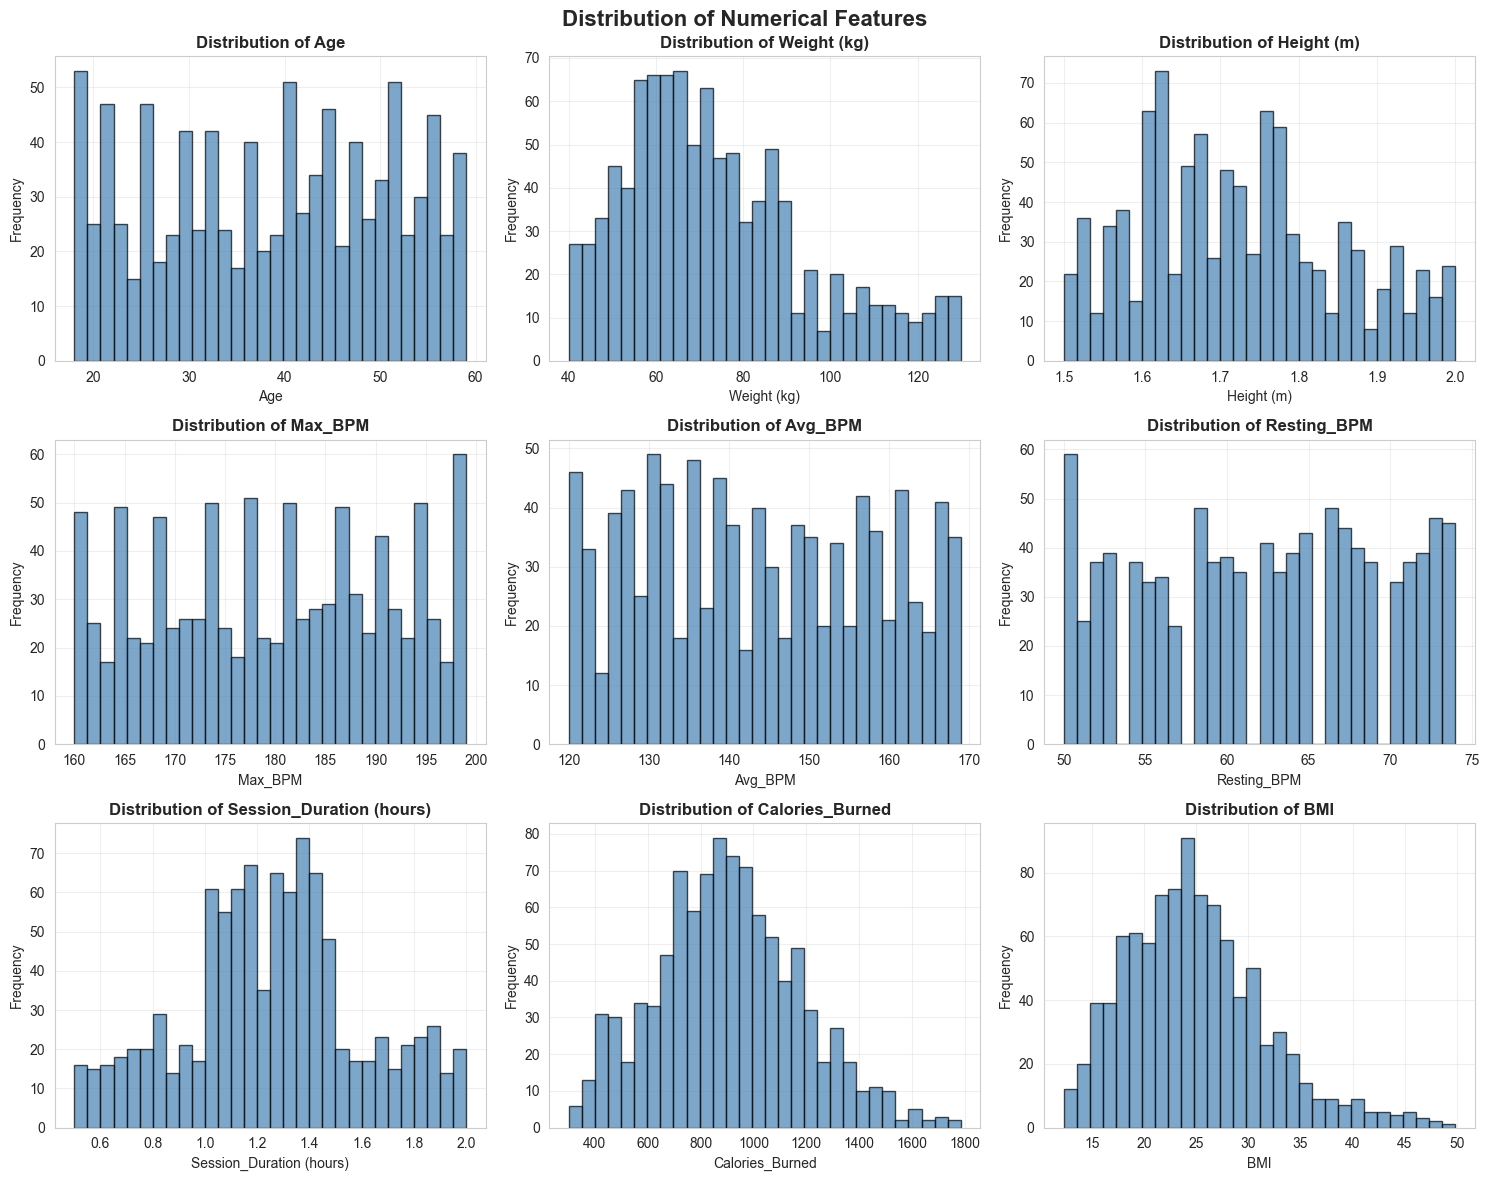

   ✅ Distribution plots displayed

2️⃣ Creating correlation heatmap...


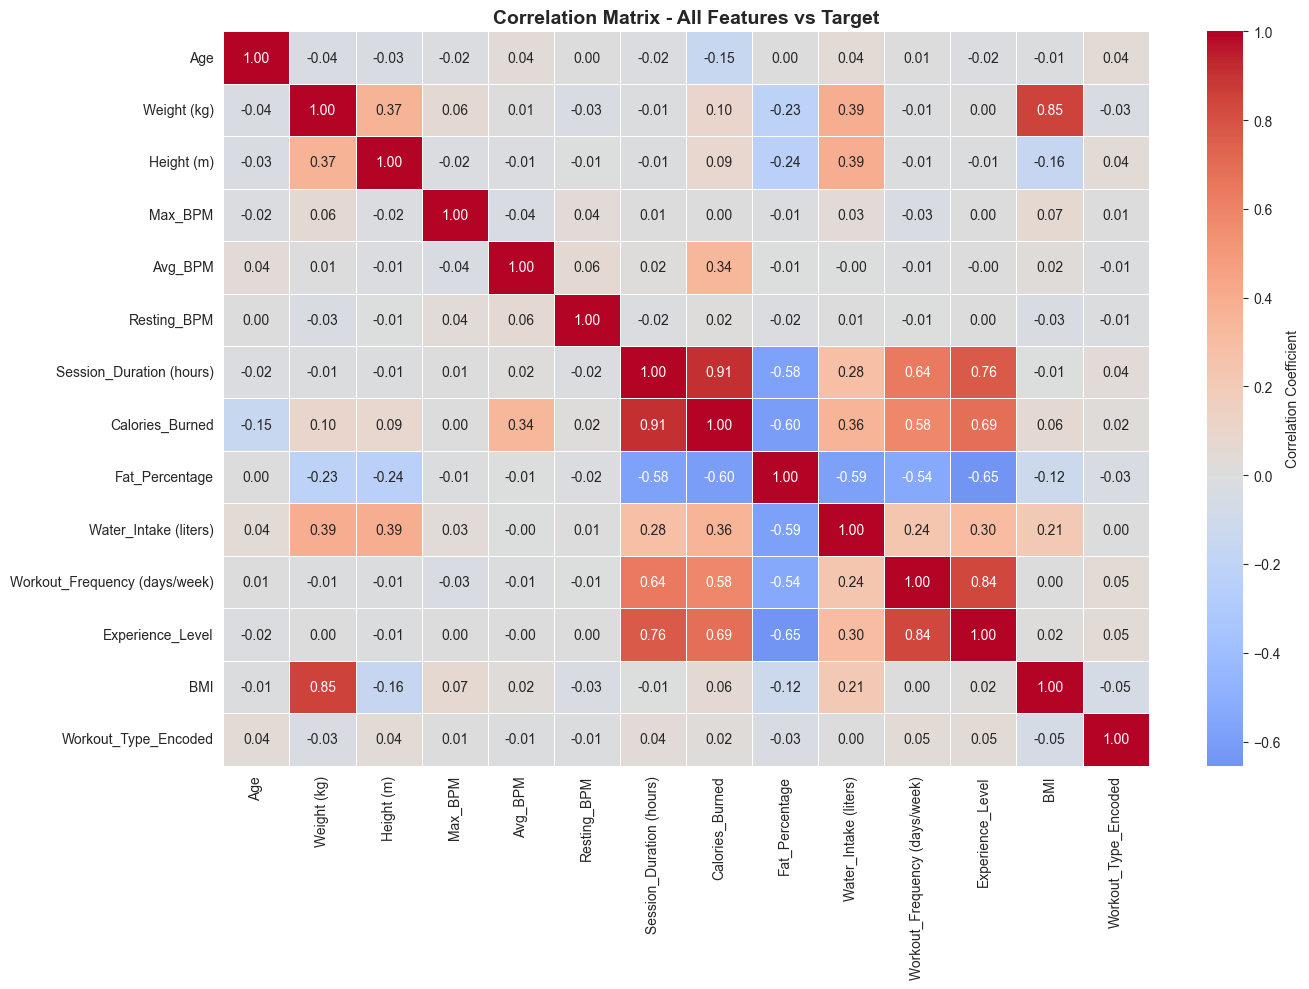

   ✅ Correlation heatmap displayed

   Top Features Correlated with Workout_Type:
Workout_Type_Encoded             1.000000
Experience_Level                 0.049993
Workout_Frequency (days/week)    0.045322
Age                              0.044296
Height (m)                       0.037712
Session_Duration (hours)         0.035443
Calories_Burned                  0.018859
Max_BPM                          0.010061
Water_Intake (liters)            0.004411
Avg_BPM                         -0.008206
Resting_BPM                     -0.011013
Weight (kg)                     -0.028724
Fat_Percentage                  -0.031913
BMI                             -0.053409
Name: Workout_Type_Encoded, dtype: float64

✅ CELL 3 COMPLETE


In [10]:
print("\n" + "=" * 80)
print("CELL 3: EDA - DISTRIBUTIONS & CORRELATIONS (A2 - Part 1)")
print("=" * 80)

# 1. Distribution plots for numerical features
print("\n1️⃣ Creating distribution plots for all numerical features...")

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')

numerical_cols = ['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 
                  'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'BMI']

for idx, col in enumerate(numerical_cols):
    row = idx // 3
    col_idx = idx % 3
    
    axes[row, col_idx].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[row, col_idx].set_title(f'Distribution of {col}', fontweight='bold')
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel('Frequency')
    axes[row, col_idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("   ✅ Distribution plots displayed")

# 2. Correlation Heatmap
print("\n2️⃣ Creating correlation heatmap...")

# Encode Workout_Type for correlation
df_corr = df.copy()
le_temp = LabelEncoder()
df_corr['Workout_Type_Encoded'] = le_temp.fit_transform(df_corr['Workout_Type'])

# Calculate correlation (numeric_only=True to skip 'Gender' and 'Workout_Type' columns)
corr_matrix = df_corr.corr(numeric_only=True)

# Plot correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Correlation Coefficient'}, linewidths=0.5)
plt.title('Correlation Matrix - All Features vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("   ✅ Correlation heatmap displayed")

# Print top correlations with target
print("\n   Top Features Correlated with Workout_Type:")
target_corr = df_corr.corr(numeric_only=True)['Workout_Type_Encoded'].sort_values(ascending=False)
print(target_corr)

print("\n" + "=" * 80)
print("✅ CELL 3 COMPLETE")
print("=" * 80)